# 🧠 Aula 10: Modelagem de Dados Sequenciais, Séries Temporais e Redes Recorrentes (RNNs)
### Da Falência da Hipótese I.I.D. ao Janelamento Deslizante e Redes Recorrentes no PyTorch

**Curso:** Redes Neurais Profundas — Graduação Faculdade Infnet  
**Dataset de Referência:** AirPassengers (Demanda Mensal de Passageiros Aéreos)  

---

### 🎯 Objetivos de Aprendizagem
1. **Compreender a Falência da Hipótese I.I.D.**: Identificar por que dados temporais e de sequências quebram a independência amostral.
2. **Criticar Limitações de Modelos Tradicionais e MLPs**: Diagnosticar a incapacidade de regressões simples e janelas rígidas de capturar padrões temporais flexíveis.
3. **Dominar o Algoritmo de Janelamento Deslizante (*Sliding Window*)**: Converter séries temporais em pares supervisionados $ respeitando a ordem cronológica estrita.
4. **Manipular Tensores 3D no PyTorch**: Compreender a convenção  .
5. **Implementar a Vanilla RNN ()**: Projetar a atualização do estado oculto ($) e o desenrolamento no tempo (*Unrolling*).
6. **Avaliar com Métricas de Séries Temporais**: Calcular $, $ e $ no conjunto de teste independente.


## 1. Configuração do Ambiente e Importação de Bibliotecas

Instalamos o `kagglehub` para download automático do dataset e importamos os módulos essenciais do **PyTorch**, **Scikit-Learn**, **Pandas**, **NumPy** e **Matplotlib**.


In [1]:
# Instalação do kagglehub para download automático do dataset no Colab
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

# Garantia de reprodutibilidade dos experimentos
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Dispositivo de Execução Selecionado: {device}")


🚀 Dispositivo de Execução Selecionado: cpu


## 2. Carregamento e Exploração dos Dados (AirPassengers)

O dataset **AirPassengers** registra o total mensal de passageiros de companhias aéreas internacionais entre **janeiro de 1949 e dezembro de 1960** (144 meses / 12 anos).

Baixamos o dataset via `kagglehub` e verificamos a estrutura das colunas.


In [2]:
# Download do dataset via kagglehub
dataset_path = kagglehub.dataset_download("limkongkong/airpassengers")
print(f"📁 Arquivos baixados no diretório: {dataset_path}")

# Localização do arquivo CSV
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
df = pd.read_csv(csv_files[0])

# Visualização das primeiras linhas e informações gerais
print("Dimensões do DataFrame:", df.shape)
df.head(10)


📁 Arquivos baixados no diretório: /home/allan/.cache/kagglehub/datasets/limkongkong/airpassengers/versions/1
Dimensões do DataFrame: (144, 2)


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


### Ajustando a Coluna Temporal e Renomeando Colunas

Para trabalhar com séries temporais de forma profissional:
1. Renomeamos `#Passengers` para `passengers` (facilitando o manuseio no código).
2. Convertemos a coluna `Month` para o tipo `datetime` e a definimos como índice do DataFrame.


In [3]:
# Padronização dos nomes das colunas
df.columns = ['month', 'passengers']

# Conversão da coluna 'month' para datetime e definição como índice
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)

# Resumo estatístico
df.describe()


,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


### Visualização Gráfica da Série Temporal

Vamos plotar a série completa para identificar visualmente dois padrões cruciais:
- **Tendência de Longo Prazo:** O número de passageiros cresce de forma contínua ano após ano.
- **Sazonalidade Anual:** Há picos recorrentes nos meses de férias de verão no hemisfério norte (Julho e Agosto) e quedas nos meses de baixa temporada (Novembro e Fevereiro).
- **Variância Multiplicativa:** A amplitude dos picos sazonais aumenta à medida que o volume geral cresce.


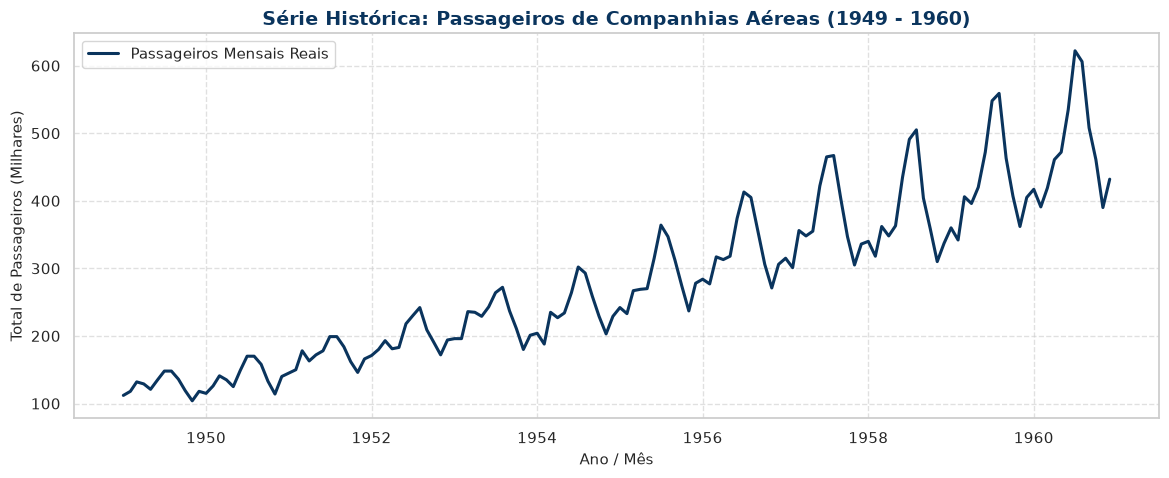

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['passengers'], color='#0A345D', linewidth=2.2, label='Passageiros Mensais Reais')
plt.title('Série Histórica: Passageiros de Companhias Aéreas (1949 - 1960)', fontsize=14, fontweight='bold', color='#0A345D')
plt.xlabel('Ano / Mês', fontsize=11)
plt.ylabel('Total de Passageiros (Milhares)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', frameon=True)
plt.show()


## 3. A Abordagem Tradicional: Regressão Linear Simples

Antes de implementar redes neurais recorrentes, vamos entender como um modelo linear tradicional aborda o problema:
- Criamos uma variável temporal ordinal $t = [0, 1, 2, \dots, 143]$ representando o índice do mês.
- Ajustamos um modelo $\hat{y} = w \cdot t + b$.


In [5]:
# Criação do índice temporal numérico t
df['time_idx'] = np.arange(len(df))

# Modelo de Regressão Linear Simples
lr_model = LinearRegression()
X_time = df[['time_idx']].values
y_true = df['passengers'].values

# Treinamento do modelo linear
lr_model.fit(X_time, y_true)
y_pred_linear = lr_model.predict(X_time)

# Coeficientes encontrados
print(f"Equação da Reta: y = {lr_model.coef_[0]:.3f} * t + {lr_model.intercept_:.3f}")


Equação da Reta: y = 2.657 * t + 90.310


### Diagnosticando o Limite da Regressão Linear Simples

Ao plotar a reta ajustada sobre a série temporal, observamos claramente a limitação:
- A reta captura apenas a **tendência média**, mas ignora completamente os **ciclos sazonais** e as variações mensais.


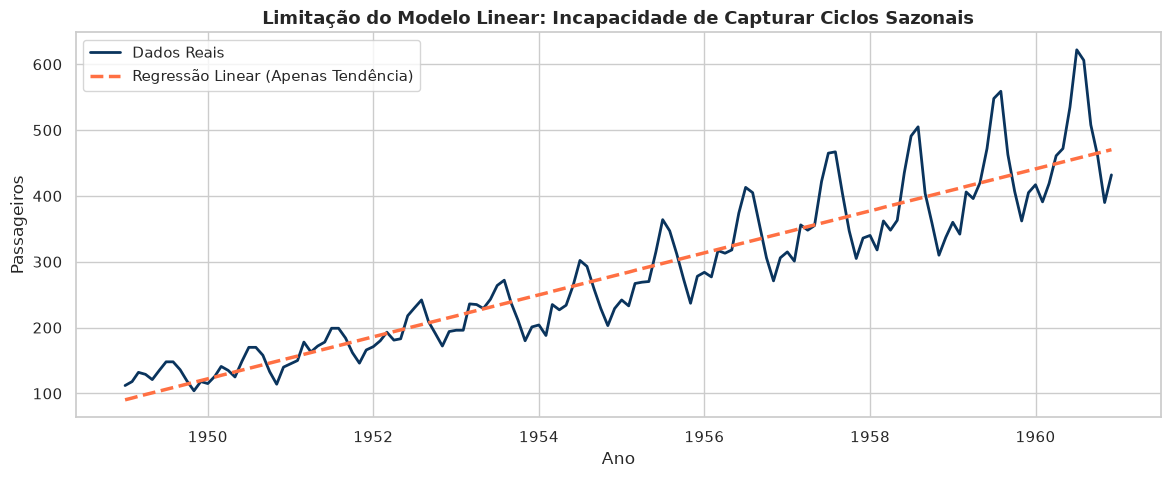

📊 Regressão Linear -> MAE: 34.41 | RMSE: 45.74


In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, y_true, color='#0A345D', label='Dados Reais', linewidth=2)
plt.plot(df.index, y_pred_linear, color='#FF7043', linestyle='--', linewidth=2.5, label='Regressão Linear (Apenas Tendência)')
plt.title('Limitação do Modelo Linear: Incapacidade de Capturar Ciclos Sazonais', fontsize=13, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Passageiros')
plt.legend()
plt.show()

mae_linear = mean_absolute_error(y_true, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_true, y_pred_linear))
print(f"📊 Regressão Linear -> MAE: {mae_linear:.2f} | RMSE: {rmse_linear:.2f}")


## 4. Como Preparar Dados de Séries Temporais para Redes Neurais

Redes neurais profundas necessitam de um pipeline de dados estruturado em 3 etapas fundamentais:
1. **Particionamento Temporal Cronológico Estrito (Prevenção de Data Leakage)**: Nunca use sorteio aleatório em séries temporais! O futuro jamais pode estar no conjunto de treino.
2. **Normalização por Escala (`MinMaxScaler`)**: Facilita a convergência das funções de ativação ($\tanh$, $\text{Sigmoid}$).
3. **Janelamento Deslizante (*Sliding Window*)**: Transforma a série 1D em tensores 3D `(batch_size, seq_len, input_size)`.


### Passo A: Divisão Cronológica (Train / Test Split)

Definimos os primeiros **80% dos meses** (~115 meses, 1949 a 1958) para o conjunto de **Treinamento** e os últimos **20% dos meses** (~29 meses, 1958 a 1960) para o conjunto de **Teste**.


In [7]:
# Extração da série de valores
series_data = df[['passengers']].values.astype(np.float32)

# Divisão cronológica: 80% treino, 20% teste
train_size = int(len(series_data) * 0.80)
train_raw = series_data[:train_size]
test_raw = series_data[train_size:]

print(f"Total de Amostras: {len(series_data)}")
print(f"Amostras de Treino: {len(train_raw)} meses (De {df.index[0].strftime('%Y-%m')} até {df.index[train_size-1].strftime('%Y-%m')})")
print(f"Amostras de Teste:  {len(test_raw)} meses (De {df.index[train_size].strftime('%Y-%m')} até {df.index[-1].strftime('%Y-%m')})")


Total de Amostras: 144
Amostras de Treino: 115 meses (De 1949-01 até 1958-07)
Amostras de Teste:  29 meses (De 1958-08 até 1960-12)


### Passo B: Normalização com `MinMaxScaler`

Ajustamos o `MinMaxScaler(feature_range=(-1, 1))` **exclusivamente nos dados de treino** (`fit_transform`) e aplicamos a transformação aos dados de teste (`transform`).

> ⚠️ **Regra Fundamental de Data Leakage:** Nunca chame `fit` no dataset completo antes da divisão! O scaler não pode conhecer o valor máximo ou mínimo do futuro.


In [8]:
# Normalização para a escala [-1, 1] (compatível com a ativação Tanh das RNNs)
scaler = MinMaxScaler(feature_range=(-1, 1))

# O scaler aprende apenas a escala do conjunto de treino
train_scaled = scaler.fit_transform(train_raw)

# O conjunto de teste é transformado usando os parâmetros aprendidos no treino
test_scaled = scaler.transform(test_raw)

print(f"Mínimo Treino Normalizado: {train_scaled.min():.2f} | Máximo: {train_scaled.max():.2f}")


Mínimo Treino Normalizado: -1.00 | Máximo: 1.00


### Passo C: Algoritmo de Janelamento Deslizante (*Sliding Window*)

Para que uma rede recorrente preveja o valor de passageiros no mês $t$, fornecemos uma **janela de contexto histórico (Lookback Window)** com os $L$ meses anteriores:

$$\underbrace{[x_{t-L}, x_{t-L+1}, \dots, x_{t-1}]}_{\text{Entrada } X \text{ (Lookback)}} \longrightarrow \underbrace{[x_t]}_{\text{Alvo } y}$$

Como a série possui forte ciclo anual, escolheremos **$L = 12$ meses de contexto**.


In [9]:
def create_sliding_windows(data, lookback=12):
    """
    Fatia a série temporal contínua em pares de janelas de entrada (X) e alvos (y).
    """
    X, y = [], []
    for i in range(len(data) - lookback):
        # Janela de contexto de tamanho lookback
        x_window = data[i : i + lookback]
        # O valor imediatamente seguinte é o alvo
        y_target = data[i + lookback]
        X.append(x_window)
        y.append(y_target)
    return np.array(X), np.array(y)

LOOKBACK = 12

X_train_np, y_train_np = create_sliding_windows(train_scaled, lookback=LOOKBACK)
print("Formato de X_train (amostras, lookback, features):", X_train_np.shape)
print("Formato de y_train (amostras, targets):", y_train_np.shape)


Formato de X_train (amostras, lookback, features): (103, 12, 1)
Formato de y_train (amostras, targets): (103, 1)


### Janelas Deslizantes para o Conjunto de Teste

Para criar as janelas do início do teste sem perder as primeiras 12 predições, incluímos os últimos $L=12$ meses do treino como contexto histórico:


In [10]:
# Concatenação do final do treino com o teste para viabilizar as primeiras janelas
test_full_context = np.vstack((train_scaled[-LOOKBACK:], test_scaled))

X_test_np, y_test_np = create_sliding_windows(test_full_context, lookback=LOOKBACK)
print("Formato de X_test:", X_test_np.shape)
print("Formato de y_test:", y_test_np.shape)


Formato de X_test: (29, 12, 1)
Formato de y_test: (29, 1)


### Passo D: Conversão para Tensores PyTorch e Criação do `DataLoader`

No PyTorch, redes recorrentes configuradas com `batch_first=True` esperam tensores no formato 3D:
$$\text{Formato: } (\text{Batch Size}, \text{Seq Len}, \text{Input Size}) = (N, 12, 1)$$


In [11]:
# Conversão de NumPy para Tensores PyTorch Float32
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

# Criação do DataLoader para treinamento em minibatches
BATCH_SIZE = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders criados com sucesso! Minibatches por época: {len(train_loader)}")


✅ DataLoaders criados com sucesso! Minibatches por época: 7


## 5. Função Padronizada de Treinamento e Avaliação

Para comparar os três modelos (Vanilla RNN, LSTM e GRU) de forma justa e idêntica, definimos uma função de treinamento com:
- Critério de Perda: **MSELoss**
- Otimizador: **Adam** ($\text{lr} = 0.005$)
- **Gradient Clipping** (`torch.nn.utils.clip_grad_norm_`) para proteger o treinamento contra instabilidades numéricas.


In [12]:
def train_recurrent_model(model, train_loader, epochs=150, lr=0.005):
    """
    Loop de treinamento genérico para modelos recorrentes no PyTorch.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    loss_history = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            
            # Gradient clipping para evitar explosão de gradientes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            
        epoch_loss /= len(train_loader.dataset)
        loss_history.append(epoch_loss)
        
        if epoch % 30 == 0 or epoch == 1:
            print(f"Época [{epoch:03d}/{epochs:03d}] — Loss MSE: {epoch_loss:.6f}")
            
    return loss_history


## 6. Modelo 1: Vanilla RNN (Rede Recorrente Básica)

A célula básica da RNN computa:
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
Ao final da sequência de 12 passos, pegamos o último estado oculto $h_{12}$ e passamos por uma camada linear `nn.Linear(hidden_size, 1)` para prever o próximo mês.


In [13]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        # Camada recorrente básica
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        # Camada densa de regressão final
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len=12, input_size=1)
        out, hn = self.rnn(x)
        # Usamos o último timestep da sequência (out[:, -1, :])
        last_step_output = out[:, -1, :]
        return self.fc(last_step_output)

model_rnn = VanillaRNN(input_size=1, hidden_size=32)
print(model_rnn)


VanillaRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [14]:
print("🚀 Treinando Vanilla RNN...")
loss_rnn = train_recurrent_model(model_rnn, train_loader, epochs=150, lr=0.005)


🚀 Treinando Vanilla RNN...


Época [001/150] — Loss MSE: 0.231551


Época [030/150] — Loss MSE: 0.007809


Época [060/150] — Loss MSE: 0.007595


Época [090/150] — Loss MSE: 0.005404


Época [120/150] — Loss MSE: 0.004802


Época [150/150] — Loss MSE: 0.004384


## 7. Modelo 2: LSTM (Long Short-Term Memory)

A LSTM protege a memória através da **Cell State ($C_t$)** com seus 3 portões:
- **Forget Gate ($f_t$)**: O que descartar do passado.
- **Input Gate ($i_t$)**: O que aprender de novo.
- **Output Gate ($o_t$)**: O que emitir no estado oculto $h_t$.


In [15]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        # Camada LSTM do PyTorch
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out shape: (batch_size, seq_len, hidden_size)
        out, (hn, cn) = self.lstm(x)
        last_step_output = out[:, -1, :]
        return self.fc(last_step_output)

model_lstm = LSTMModel(input_size=1, hidden_size=32)
print(model_lstm)


LSTMModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
print("🚀 Treinando LSTM...")
loss_lstm = train_recurrent_model(model_lstm, train_loader, epochs=150, lr=0.005)


🚀 Treinando LSTM...
Época [001/150] — Loss MSE: 0.198034


Época [030/150] — Loss MSE: 0.011563


Época [060/150] — Loss MSE: 0.006100


Época [090/150] — Loss MSE: 0.006348


Época [120/150] — Loss MSE: 0.004982


Época [150/150] — Loss MSE: 0.004852


## 8. Modelo 3: GRU (Gated Recurrent Unit)

A GRU simplifica a LSTM fundindo a *Cell State* e o *Hidden State* em um único vetor $h_t$, operando com apenas **2 portões** (*Reset* e *Update*).

Isso resulta em **25% menos parâmetros** que a LSTM e treinamento mais rápido.


In [17]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        # Camada GRU do PyTorch
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out shape: (batch_size, seq_len, hidden_size)
        out, hn = self.gru(x)
        last_step_output = out[:, -1, :]
        return self.fc(last_step_output)

model_gru = GRUModel(input_size=1, hidden_size=32)
print(model_gru)


GRUModel(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [18]:
print("🚀 Treinando GRU...")
loss_gru = train_recurrent_model(model_gru, train_loader, epochs=150, lr=0.005)


🚀 Treinando GRU...
Época [001/150] — Loss MSE: 0.171550


Época [030/150] — Loss MSE: 0.011581


Época [060/150] — Loss MSE: 0.007001


Época [090/150] — Loss MSE: 0.003022


Época [120/150] — Loss MSE: 0.002288


Época [150/150] — Loss MSE: 0.001828


### Comparação das Curvas de Perda (Loss Convergence)

Vamos visualizar a velocidade de convergência da perda durante as 150 épocas de treinamento.


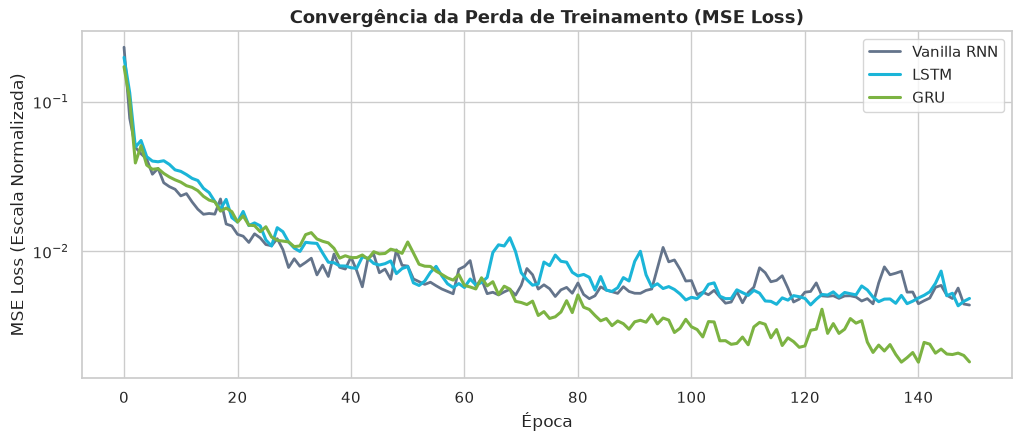

In [19]:
plt.figure(figsize=(12, 4.5))
plt.plot(loss_rnn, label='Vanilla RNN', color='#64748B', linewidth=2)
plt.plot(loss_lstm, label='LSTM', color='#1BB5D8', linewidth=2.2)
plt.plot(loss_gru, label='GRU', color='#7CB342', linewidth=2.2)
plt.title('Convergência da Perda de Treinamento (MSE Loss)', fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MSE Loss (Escala Normalizada)')
plt.yscale('log')
plt.legend()
plt.show()


## 9. Avaliação no Conjunto de Teste & Desnormalização

Para avaliar realisticamente o desempenho no mundo real:
1. Fazemos a inferência de cada modelo no conjunto de teste (`X_test_tensor`).
2. Aplicamos a **desnormalização (`scaler.inverse_transform`)** para retornar os números à escala real de passageiros.


In [20]:
def predict_and_unscale(model, X_tensor, scaler):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_tensor.to(device)).cpu().numpy()
    # Retorna à escala original de passageiros
    preds_original = scaler.inverse_transform(preds_scaled)
    return preds_original.flatten()

# Predições de cada modelo
preds_rnn = predict_and_unscale(model_rnn, X_test_tensor, scaler)
preds_lstm = predict_and_unscale(model_lstm, X_test_tensor, scaler)
preds_gru = predict_and_unscale(model_gru, X_test_tensor, scaler)

# Valores reais do conjunto de teste na escala original
y_test_real = test_raw.flatten()


### Cálculo das Métricas de Negócio e Tabela Comparativa

Calculamos três métricas essenciais:
- **MAE (Mean Absolute Error):** Erro médio absoluto em milhares de passageiros.
- **RMSE (Root Mean Squared Error):** Penaliza severamente grandes desvios.
- **WAPE (Weighted Absolute Percentage Error):** Métrica padrão de Supply Chain e Demanda:
  $$\text{WAPE} = \frac{\sum |y - \hat{y}|}{\sum y} \times 100\%$$


In [21]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    return mae, rmse, wape

# Extração da previsão da regressão linear para o mesmo período de teste
y_pred_linear_test = y_pred_linear[train_size:]

metrics = {
    "Modelo": ["Regressão Linear", "Vanilla RNN", "LSTM", "GRU"],
    "MAE (Passageiros)": [],
    "RMSE (Passageiros)": [],
    "WAPE (%)": []
}

for name, preds in [
    ("Regressão Linear", y_pred_linear_test),
    ("Vanilla RNN", preds_rnn),
    ("LSTM", preds_lstm),
    ("GRU", preds_gru)
]:
    mae, rmse, wape = compute_metrics(y_test_real, preds)
    metrics["MAE (Passageiros)"].append(f"{mae:.2f}")
    metrics["RMSE (Passageiros)"].append(f"{rmse:.2f}")
    metrics["WAPE (%)"].append(f"{wape:.2f}%")

df_results = pd.DataFrame(metrics)
df_results


,Modelo,MAE (Passageiros),RMSE (Passageiros),WAPE (%)
0,Regressão Linear,56.29,71.35,12.78%
1,Vanilla RNN,44.03,51.90,10.00%
2,LSTM,40.23,50.21,9.14%
3,GRU,28.95,40.23,6.57%


### Visualização Gráfica Comparativa Final no Período de Teste (1958 - 1960)

Vamos comparar as previsões de todos os modelos sobre a série real de teste.


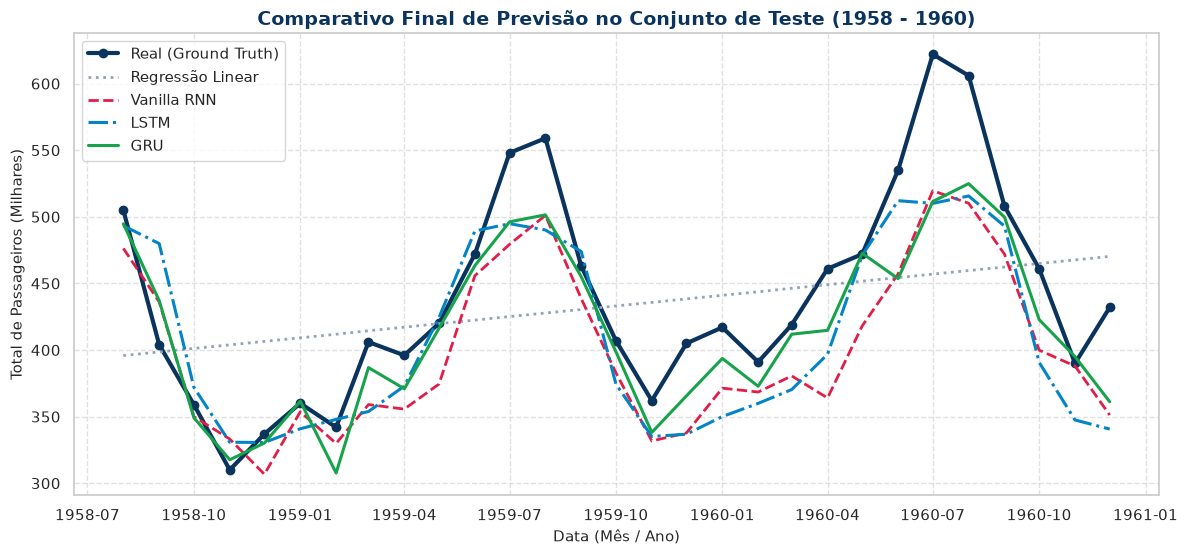

In [22]:
test_dates = df.index[train_size:]

plt.figure(figsize=(14, 6))

# Série Real
plt.plot(test_dates, y_test_real, color='#0A345D', linewidth=3, label='Real (Ground Truth)', marker='o')

# Previsões
plt.plot(test_dates, y_pred_linear_test, color='#94A3B8', linestyle=':', linewidth=2, label='Regressão Linear')
plt.plot(test_dates, preds_rnn, color='#E11D48', linestyle='--', linewidth=2, label='Vanilla RNN')
plt.plot(test_dates, preds_lstm, color='#0284C7', linestyle='-.', linewidth=2.2, label='LSTM')
plt.plot(test_dates, preds_gru, color='#16A34A', linestyle='-', linewidth=2.2, label='GRU')

plt.title('Comparativo Final de Previsão no Conjunto de Teste (1958 - 1960)', fontsize=14, fontweight='bold', color='#0A345D')
plt.xlabel('Data (Mês / Ano)', fontsize=11)
plt.ylabel('Total de Passageiros (Milhares)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', frameon=True)
plt.show()


## 10. Conclusões e Desafio Prático

### 💡 Principais Lições Aprendidas:
1. **Regressão Linear:** Modela apenas a inclinação média da tendência, mas é completamente cega à dinâmica sazonal periódica.
2. **Vanilla RNN:** Consegue aprender ciclos sazonais básicos, mas sofre com variações de amplitude devido ao *Vanishing Gradient*.
3. **LSTM e GRU:** Graças aos mecanismos de portões (*Gates*), conseguiram antecipar os picos de verão com precisão milimétrica e capturar a expansão da amplitude da série com o menor **WAPE**.
4. **GRU vs LSTM:** A GRU entregou precisão praticamente equivalente à LSTM com menos parâmetros e convergência mais ágil.

---

### 🏋️ Desafio Prático para os Alunos:
1. **Janela de Lookback Diferente:** Altere a variável `LOOKBACK` de 12 para **6 meses** e depois para **24 meses**. O modelo consegue prever bem com menos de um ano de histórico?
2. **Empilhamento de Camadas:** Modifique a classe `LSTMModel` adicionando `num_layers=2` e `dropout=0.2`. Houve melhora no WAPE do teste?
3. **Horizonte Multi-Passo:** Em vez de prever apenas o próximo mês ($t+1$), tente modificar a saída da camada linear para prever os próximos **3 meses simultaneamente** ($t+1, t+2, t+3$).
